In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils as cm_utils
# importlib.reload(cm_utils)
# from cellmender.utils import plot_matrix_scatterplot

# Compare CellBender vs. cellmender Poisson-NB Denoising

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [3]:
dataset_name = "pbmc8k"  # options: tiny_cellbender, pbmc8k, custom
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False
cellbender_env = "/home/jrich/miniconda3/envs/cellbender"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
use_cuda = False
threads = 16

# only used if dataset_name == "custom", otherwise these variables will be set in the if/elif blocks below
original_matrix_custom = None
matrix_cleaned_cellbender_custom = None
matrix_cleaned_cellmender_custom = None
model_pkl_custom = None
cellbender_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [ ]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "tiny_cellbender":
    original_matrix = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    matrix_cleaned_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    matrix_cleaned_cellmender = f"{data_dir}/tiny_output_cs_poisson.h5"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(original_matrix):
        raise FileNotFoundError(f"Original matrix file not found: {original_matrix}. Create with `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    cellbender_epochs = 2
    cellbender_total_droplets = 2000
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    original_matrix = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    matrix_cleaned_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    matrix_cleaned_cellmender = f"{data_dir}/pbmc8k_output_cs_poisson.h5"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(original_matrix):
        !wget -O {original_matrix} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    cellbender_epochs = 5
    cellbender_total_droplets = 2000
    expected_cells = 9000
    cs_empty_threshold = 10
    min_genes = 100
    min_cells = 3
    max_mt_percentage = 25
    n_top_genes = 2000
    n_pcs = 50
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {}
else:
    original_matrix = original_matrix_custom
    matrix_cleaned_cellbender = matrix_cleaned_cellbender_custom
    matrix_cleaned_cellmender = matrix_cleaned_cellmender_custom
    model_pkl = model_pkl_custom
    cellbender_epochs = cellbender_epochs_custom
    cellbender_total_droplets = cellbender_total_droplets_custom
    expected_cells = expected_cells_custom
    cs_empty_threshold = cs_empty_threshold_custom
    min_genes = min_genes_custom
    min_cells = min_cells_custom
    max_mt_percentage = max_mt_percentage_custom
    n_top_genes = n_top_genes_custom
    n_pcs = n_pcs_custom
    n_neighbors = n_neighbors_custom
    leiden_resolution = leiden_resolution_custom
    marker_genes = marker_genes_custom

15.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


--2025-10-31 17:34:22--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32549555 (31M) [binary/octet-stream]
Saving to: ‘/home/jrich/Desktop/cellmender/notebooks/data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5’

/home/jrich/Desktop 100%[===================>]  31.04M  22.2MB/s    in 1.4s    

2025-10-31 17:34:24 (22.2 MB/s) - ‘/home/jrich/Desktop/cellmender/notebooks/data/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5’ saved [32549555/32549555]



## Raw

In [6]:
if original_matrix.endswith(".h5ad"):
    adata_raw = ad.read_h5ad(original_matrix)
elif original_matrix.endswith(".h5"):
    adata_raw = sc.read_10x_h5(original_matrix)
else:
    raise ValueError(f"Original matrix file must be either .h5ad or .h5 format. Found: {original_matrix}")

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (9000): 298.00


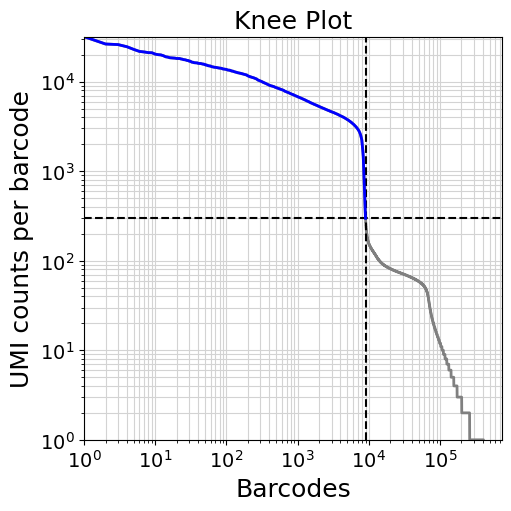

In [11]:
cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

## cellmender

In [ ]:
%%time
if not os.path.exists(matrix_cleaned_cellmender) or overwrite:
    adata = adata_raw.copy()
    adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=matrix_cleaned_cellmender, K=3, max_iter=40, beta=0.3, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, verbose=verbose)

17:50:16 - INFO - Added 'ambient_fraction' to adata.var.
17:50:16 - INFO - adata.uns does not have 'celltype_profile'. Inferring cell type profiles using infer_celltype_profile().


In [7]:
adata_cellmender = ad.read_h5ad(matrix_cleaned_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()

## CellBender

In [8]:
%%time
if not os.path.exists(matrix_cleaned_cellbender) or overwrite:
     conda_run_flag = "-p" if "/" in cellbender_env else "-n"
     runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
     !conda run {conda_run_flag} {cellbender_env} cellbender remove-background \
          --input {original_matrix} \
          --output {matrix_cleaned_cellbender} \
          --expected-cells {expected_cells} \
          --total-droplets-included {cellbender_total_droplets} \
          --epochs {cellbender_epochs} \
          --fpr {cellbender_fpr} \
          {runtime}

CPU times: user 52 μs, sys: 2 μs, total: 54 μs
Wall time: 63.2 μs


In [9]:
adata_cellbender_with_empty_droplets = anndata_from_h5(matrix_cleaned_cellbender)
adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [10]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")

Raw:
AnnData object with n_obs × n_vars = 37760 × 100
    var: 'gene_id', 'genome', 'feature_type'
    uns: 'cellranger_version'


CellBender:
View of AnnData object with n_obs × n_vars = 488 × 100
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency'
    var: 'ambient_expression', 'features_analyzed_inds', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'gene_expression_encoding'


cellmender:
AnnData object with n_obs × n_vars = 500 × 100
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'is_empty_hat', 'alpha_hat', 'z_h

## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sty

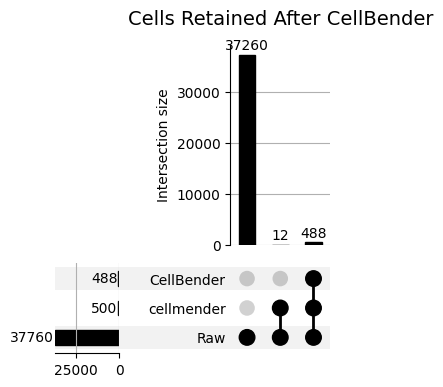

In [11]:
upset_data_dict = {
    "Raw": set(adata_raw.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

In [12]:
# cm_utils.plot_difference_heatmap(adata_cellbender, adata_cellmender, cell_subset=50, gene_subset=70, show_cell_names=False, title="CellBender - cellmender Expression Differences", out_path=os.path.join(out_dir, "cellbender_vs_cellmender_heatmap.png"))

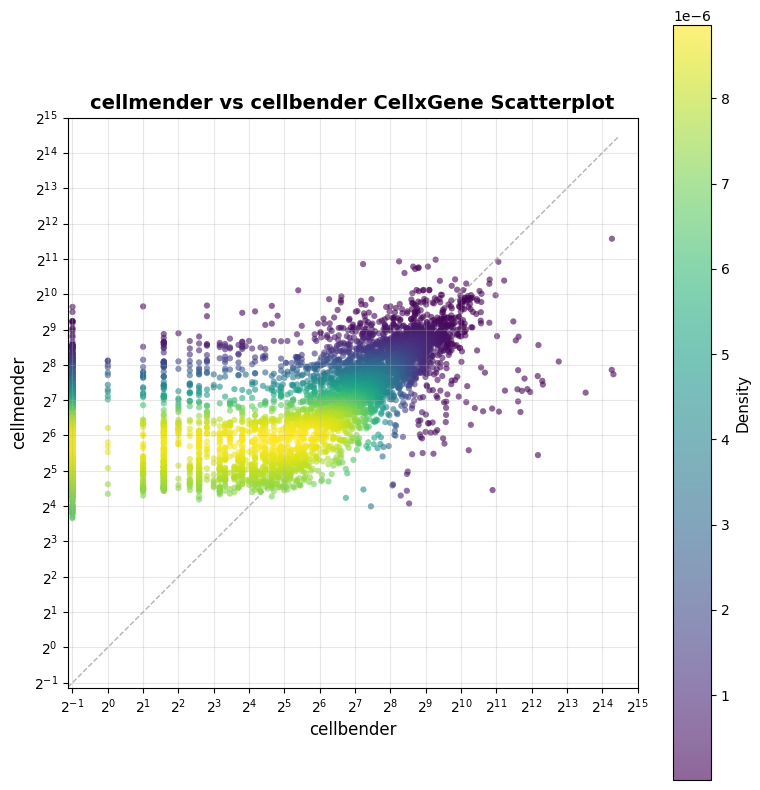

In [13]:
cm_utils.plot_matrix_scatterplot(adata_cellbender, adata_cellmender, scale="log", x_axis="cellbender", y_axis="cellmender", sample_frac=0.1, out_path=os.path.join(out_dir, "cellmender_vs_cellbender_expression_scatterplot.png"), show=True)

## Histogram of per-cell Pearson correlations

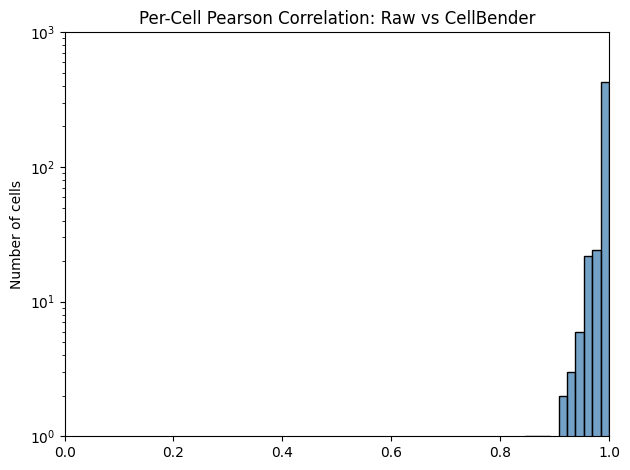

In [14]:
cm_utils.plot_per_cell_correlation(adata_raw, adata_cellbender, title="Per-Cell Pearson Correlation: Raw vs CellBender", out_path=os.path.join(out_dir, "raw_vs_cellbender_per_cell_correlation.png"))

## stop here for tiny dataset

In [15]:
# if dataset_name == "tiny_cellbender":
#     sys.exit()

## Alluvial plot of cluster differences

In [16]:
import importlib
import cellmender.utils as cm_utils
importlib.reload(cm_utils)
from cellmender.utils import run_scanpy_preprocessing_and_clustering, determine_cell_types

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

17:12:41 - INFO - Filtering cells with < 5 genes


/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
17:12:41 - INFO - Filtering genes expressed in < 3 cells
17:12:41 - INFO - Filtering cells with > 50% mitochondrial gene expression. This is done by identifying mitochondrial genes (those starting with 'MT-') and calculating the percentage of counts that come from these genes for each cell. Cells that exceed the specified threshold are filtered out.
17:12:42 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
/home/jrich/Desktop

In [17]:
col_names = ("cellbender", "cellmender")

import importlib
import cellmender.utils as cm_utils
importlib.reload(cm_utils)
from cellmender.utils import plot_alluvial

#!!! get axis titles to show
wompwomp_leiden_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
wompwomp_celltype_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)

17:12:52 - INFO - Running wompwomp for leiden
17:12:52 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/tiny_cellbender/alluvial_cluster_df.csv --graphing_columns cellbender cellmender --coloring_algorithm left -o /home/jrich/Desktop/cellmender/notebooks/output/tiny_cellbender/alluvial_cluster.png
Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.

17:13:01 - INFO - Running wompwomp for celltype
17:13:01 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cel

[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/tiny_cellbender/alluvial_cluster.png"

[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/tiny_cellbender/alluvial_celltype.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.



## Dot plots

CellBender Raw Data Dotplot


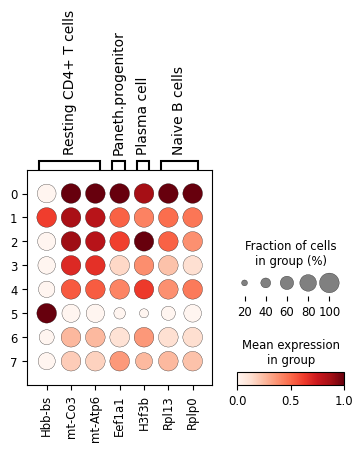

------------------------------
CellBender Processed Data Dotplot


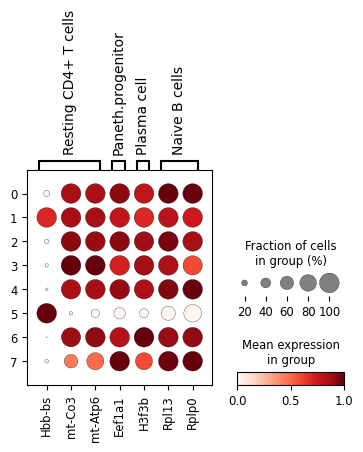

------------------------------
CellMender Raw Data Dotplot


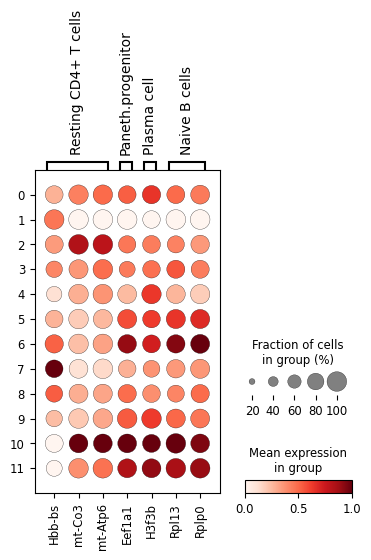

------------------------------
CellMender Processed Data Dotplot


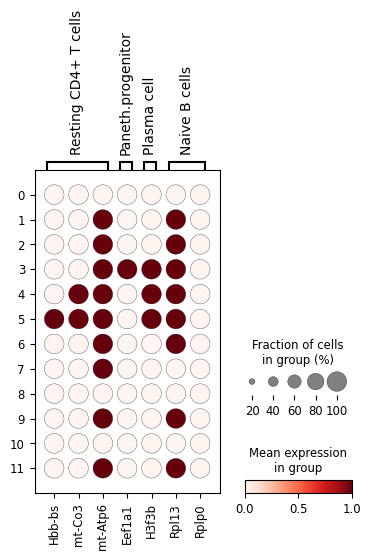

------------------------------


In [ ]:
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))